X shape: (360, 24, 51)
y shape: (360,)


epoch,train_loss,valid_loss,accuracy,time
0,1.800732,1.783204,0.177778,00:00
1,1.722523,1.781689,0.227778,00:00
2,1.633335,1.777538,0.233333,00:00
3,1.522221,1.768263,0.244444,00:00
4,1.401275,1.749589,0.266667,00:00
5,1.283239,1.714421,0.411111,00:00
6,1.170549,1.648407,0.561111,00:00
7,1.071501,1.533400,0.683333,00:00
8,0.986829,1.356532,0.783333,00:00
9,0.909862,1.103577,0.822222,00:00


[0.10905765742063522, 0.9555555582046509]

Validation accuracy: 0.9556



Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       0.93      0.87      0.90        30
           2       0.88      0.97      0.92        30
           3       1.00      0.97      0.98        30
           4       0.97      1.00      0.98        30
           5       1.00      0.97      0.98        30

    accuracy                           0.96       180
   macro avg       0.96      0.96      0.96       180
weighted avg       0.96      0.96      0.96       180



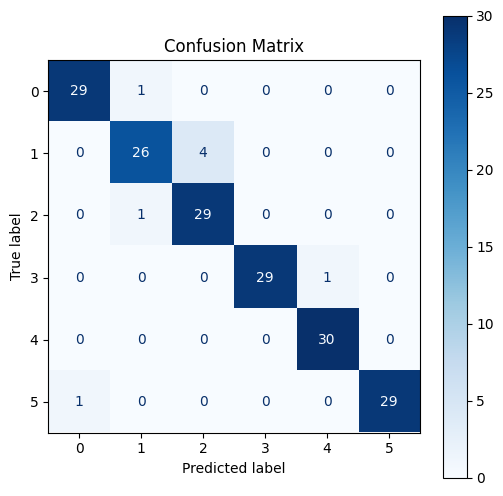

In [1]:
from fastai.callback.tracker import SaveModelCallback

from tsai.all import *
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np



set_seed(42, reproducible=True)



X, y, splits = get_classification_data(
    'NATOPS',
    split_data=False,
    return_split=True
)

print("X shape:", X.shape)
print("y shape:", y.shape)



tfms = [None, TSClassification()]

batch_tfms = TSStandardize()

dls = get_ts_dls(
    X,
    y,
    splits=splits,
    tfms=tfms,
    batch_tfms=batch_tfms,
    bs=64
)



model = InceptionTime(
    dls.vars,       # number of channels
    dls.c           # number of classes
)



learn = Learner(
    dls,
    model,
    metrics=accuracy
)



learn.fit_one_cycle(
    50,
    1e-3
)

results = learn.validate()

print(results)

val_loss = results[0]
val_acc  = results[1]

print(f"\nValidation accuracy: {val_acc:.4f}")


preds, targets = learn.get_preds()

pred_labels = preds.argmax(dim=1).cpu().numpy()
true_labels = targets.cpu().numpy()


print("\nClassification Report:")
print(
    classification_report(
        true_labels,
        pred_labels
    )
)


cm = confusion_matrix(true_labels, pred_labels)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix")

plt.show()

Baseline accuracy: 0.9556

Most important channels:
----------------------------------------
01. Channel 03 | Drop = 0.2889
02. Channel 01 | Drop = 0.1722
03. Channel 22 | Drop = 0.1444
04. Channel 21 | Drop = 0.1444
05. Channel 09 | Drop = 0.1389
06. Channel 04 | Drop = 0.1278
07. Channel 11 | Drop = 0.1222
08. Channel 10 | Drop = 0.0944
09. Channel 16 | Drop = 0.0667
10. Channel 02 | Drop = 0.0500
11. Channel 07 | Drop = 0.0444
12. Channel 15 | Drop = 0.0389
13. Channel 19 | Drop = 0.0333
14. Channel 05 | Drop = 0.0333
15. Channel 23 | Drop = 0.0278
16. Channel 13 | Drop = 0.0167
17. Channel 14 | Drop = 0.0167
18. Channel 17 | Drop = 0.0111
19. Channel 12 | Drop = 0.0056
20. Channel 08 | Drop = 0.0000
21. Channel 06 | Drop = 0.0000
22. Channel 20 | Drop = -0.0056
23. Channel 00 | Drop = -0.0056
24. Channel 18 | Drop = -0.0111


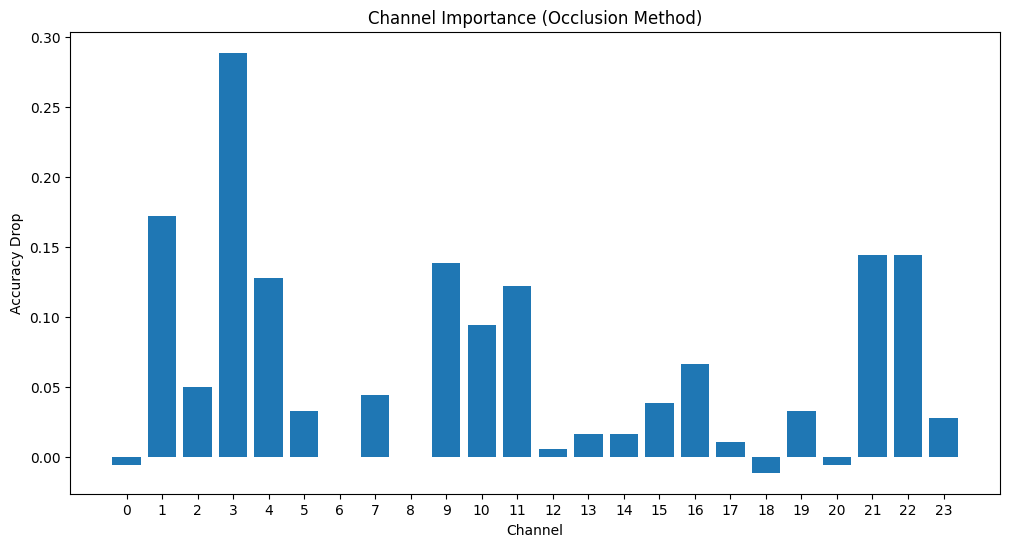

In [2]:
from sklearn.metrics import accuracy_score
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get validation data
# ------------------------------------------------------------

xb_list = []
yb_list = []

for xb, yb in learn.dls.valid:
    xb_list.append(xb.cpu())
    yb_list.append(yb.cpu())

X_valid = torch.cat(xb_list)
y_valid = torch.cat(yb_list)

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

learn.model.eval()

with torch.no_grad():

    preds = learn.model(X_valid.to(default_device()))

pred_labels = preds.argmax(dim=1).cpu().numpy()

baseline_acc = accuracy_score(
    y_valid.numpy(),
    pred_labels
)

print(f"Baseline accuracy: {baseline_acc:.4f}")

# ------------------------------------------------------------
# Channel importance
# ------------------------------------------------------------

n_channels = X_valid.shape[1]

drops = []

for ch in range(n_channels):

    X_occ = X_valid.clone()

    # remove channel
    X_occ[:, ch, :] = 0

    with torch.no_grad():

        preds_occ = learn.model(
            X_occ.to(default_device())
        )

    pred_labels_occ = (
        preds_occ.argmax(dim=1)
        .cpu()
        .numpy()
    )

    acc_occ = accuracy_score(
        y_valid.numpy(),
        pred_labels_occ
    )

    drop = baseline_acc - acc_occ

    drops.append(drop)

# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------

importance_order = np.argsort(drops)[::-1]

print("\nMost important channels:")
print("-" * 40)

for rank, ch in enumerate(importance_order):

    print(
        f"{rank+1:02d}. "
        f"Channel {ch:02d} | "
        f"Drop = {drops[ch]:.4f}"
    )



plt.figure(figsize=(12, 6))

plt.bar(
    np.arange(n_channels),
    drops
)

plt.xlabel("Channel")
plt.ylabel("Accuracy Drop")
plt.title("Channel Importance (Occlusion Method)")

plt.xticks(np.arange(n_channels))

plt.show()

Slični importance rezultati kao i Hydra - moguće da su identificirani obrasci stvarno povezani sa strukturom podataka, a ne samo sa specifičnostima pojedinog modela.

* kanal 03 (Hand tip right, X),
* kanal 01 (Hand tip left, Y),
* kanali 21 i 22 (Thumb right, X/Y),
* te kanali 09–11 (Elbow right, X/Y/Z).

Rezultati ukazuju da modeli najveću pažnju pridaju pokretima šake, palca i lakta, odnosno koordinatama koje najbolje opisuju dinamiku izvođenja geste. S druge strane, pojedini kanali imali su vrlo mali ili čak negativan utjecaj na točnost modela, što sugerira da određene koordinate sadrže redundantne ili manje korisne informacije.
